# **objective: EDA and preprocessing**
## dataset : https://github.com/ageron/data/raw/main/housing.tgz

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import tarfile
import urllib.request
import matplotlib.pyplot as plt

In [2]:
def load_housing_data():
    tarbal_path = Path("datasets/housing.tgz")
    if not tarbal_path.is_file():
        Path("./datasets").mkdir(parents=True,exist_ok=True)
        url = "https://github.com/ageron/data/raw/main/housing.tgz"
        urllib.request.urlretrieve(url , tarbal_path)
        with tarfile.open(tarbal_path) as housing_tarball:
            housing_tarball.extractall(path="./datasets")
    return pd.read_csv(Path("./datasets/housing/housing.csv"))

In [3]:
housing = load_housing_data()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


#### initial understanding
- on top of our mind we may initially assume that each row is the feature of a house
- but wait , consider 1st row
    - can there be 880 total_rooms , or 129 total_bedrooms.
    - seems funny right.
    - do further analysis

In [4]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


#### There are 9 columns of numerical data type.
#### and 1 column with string or object data type.

In [5]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [6]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

#### now we see that there are null values in cloumn "total_bedrooms"

In [7]:
housing[housing.isnull().any(axis=1)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
182,-118.27,34.04,13.0,1784.0,NaN,2158.0,682.0,1.7038,118100.0,<1H OCEAN
327,-117.65,34.04,15.0,3393.0,NaN,2039.0,611.0,3.9336,151000.0,INLAND
366,-122.50,37.75,44.0,1819.0,NaN,1137.0,354.0,3.4919,271800.0,NEAR OCEAN
477,-117.99,34.14,30.0,2346.0,NaN,1988.0,474.0,2.5625,153000.0,INLAND
495,-114.59,34.83,41.0,812.0,NaN,375.0,158.0,1.7083,48500.0,INLAND
...,...,...,...,...,...,...,...,...,...,...
19880,-118.23,33.94,36.0,1110.0,NaN,1417.0,302.0,2.3333,92100.0,<1H OCEAN
19952,-119.19,34.20,18.0,3620.0,NaN,3171.0,779.0,3.3409,220500.0,NEAR OCEAN
20088,-119.73,36.83,8.0,3602.0,NaN,1959.0,580.0,5.3478,138800.0,INLAND
20325,-118.88,34.17,15.0,4260.0,NaN,1701.0,669.0,5.1033,410700.0,<1H OCEAN


#### Before doing anything to the "total_bedrooms" column lets se how it is corelated to the target "median_house_value"

In [8]:
new_housing = housing.drop(columns=["ocean_proximity"])
# new_housing.corr(housing["median_house_value"])
corr_matrix = new_housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

## now lets understand the data with the graphical representation

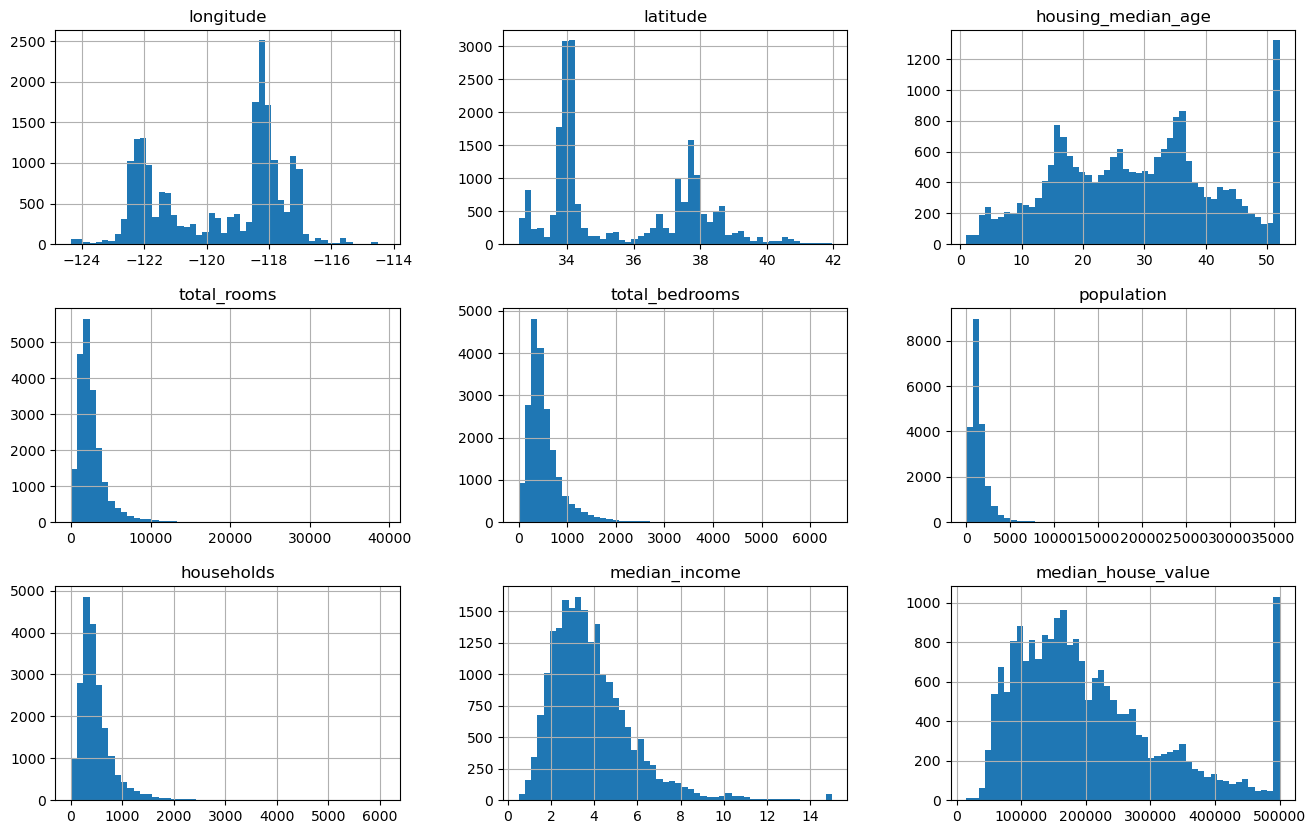

In [9]:
housing.hist(bins=50 , figsize=(16,10))
plt.show()

#### From these Hist graphs we can say that
- median_income x-axis , no individual could be me making a single digit income, there must have been some processing or transformation done priorly.
- the dataset has no record of house that are older than 54 or 55 .
- it does not have a record of house value greater than 500,000.
- most of the graph are skewed towards right.(i.e majority of the values lie towards left of the graph)

### Now its time to go back to the clients and askk all the doubts that you have regarding the data you are dealing with


------------------------------------------------------------------------------------------------------------



## after getting back from the clients you may have clear picture of the dataset.

### lets apply some processing techniques , but before that lets split the data

---------------------------------
## - splitting techniques
        - using classic train_test_split
        - using stratified_shuffle_split (here we ensure there is a strategy for the splitting process)

In [10]:
from sklearn.model_selection import train_test_split

train_set , test_set = train_test_split(housing , test_size=0.2 , random_state=30)

In [11]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16339.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.574402,35.638633,28.607740,2641.978864,539.037273,1427.268350,500.403222,3.863293,206134.579215
std,2.005996,2.136569,12.580801,2201.136430,423.199836,1114.546557,383.418536,1.901974,115308.077871
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1448.000000,297.000000,789.000000,281.000000,2.557650,118800.000000
50%,-118.500000,34.260000,29.000000,2128.000000,435.000000,1170.000000,410.000000,3.522900,179400.000000
75%,-118.010000,37.720000,37.000000,3162.000000,650.000000,1729.000000,607.000000,4.725000,263800.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,28566.000000,6082.000000,15.000100,500001.000000


In [12]:
test_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,4128.000000,4128.000000,4128.000000,4128.000000,4094.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,-119.550913,35.604775,28.766473,2610.899952,533.214216,1418.310320,496.085514,3.900183,209740.767684
std,1.993775,2.133526,12.605291,2101.793841,414.081486,1201.570628,377.969575,1.891128,115714.150397
min,-124.260000,32.560000,1.000000,12.000000,3.000000,8.000000,2.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1446.000000,292.000000,780.750000,277.000000,2.586175,122500.000000
50%,-118.470000,34.230000,29.000000,2118.500000,433.000000,1149.500000,407.000000,3.580500,181300.000000
75%,-117.980000,37.700000,37.000000,3096.000000,634.000000,1713.000000,595.000000,4.816850,269800.000000
max,-114.580000,41.950000,52.000000,26322.000000,4819.000000,35682.000000,4769.000000,15.000100,500001.000000


#### - stratified split
        - the client may have said the income category affects the most for median_house_value

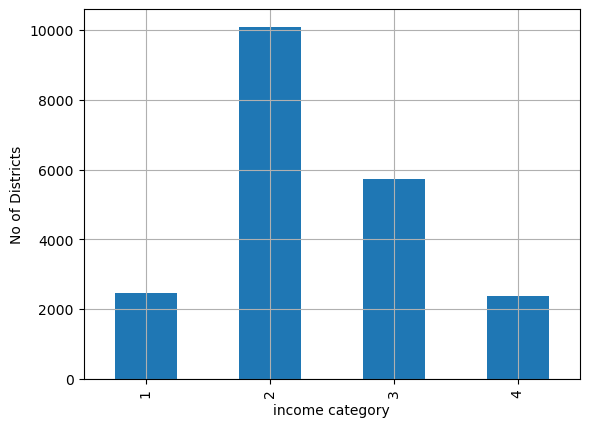

In [13]:
# creating a new column income_cat

housing["income_cat"] = pd.cut(housing["median_income"] , bins=[0.,2.,4.,6.,np.inf],labels=[1,2,3,4])

housing["income_cat"].value_counts().sort_index().plot(kind='bar',grid=True)
plt.xlabel("income category")
plt.ylabel("No of Districts")
plt.show()

In [14]:
strat_train_set , strat_test_set = train_test_split(housing , test_size=0.2 , stratify=housing["income_cat"],random_state=42)

In [15]:
strat_train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,16512.000000,16512.000000,16512.000000,16512.000000,16348.000000,16512.000000,16512.000000,16512.000000,16512.000000
mean,-119.564094,35.627174,28.637173,2612.883963,533.686934,1414.387294,496.207183,3.865925,206525.167938
std,2.005064,2.134512,12.612302,2121.451704,413.941234,1108.127797,375.874019,1.898644,115239.470577
min,-124.350000,32.540000,1.000000,2.000000,1.000000,5.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1443.000000,295.000000,785.000000,279.000000,2.555825,119200.000000
50%,-118.490000,34.250000,29.000000,2118.000000,433.000000,1165.000000,408.000000,3.529550,179500.000000
75%,-118.010000,37.710000,37.000000,3137.000000,645.000000,1720.000000,603.000000,4.750000,264500.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [16]:
strat_test_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,4128.000000,4128.000000,4128.000000,4128.000000,4085.000000,4128.000000,4128.000000,4128.000000,4128.000000
mean,-119.592146,35.650610,28.648740,2727.279554,554.613219,1469.834545,512.869671,3.889657,208178.412791
std,1.997477,2.141862,12.479522,2405.382718,449.607924,1224.113435,406.905272,1.904638,116022.688152
min,-124.230000,32.550000,1.000000,15.000000,4.000000,3.000000,2.000000,0.499900,14999.000000
25%,-121.820000,33.940000,18.000000,1469.000000,299.000000,793.000000,282.000000,2.608000,121400.000000
50%,-118.510000,34.270000,29.000000,2167.500000,445.000000,1171.000000,415.000000,3.558300,180800.000000
75%,-118.010000,37.720000,37.000000,3177.250000,656.000000,1749.000000,609.000000,4.722200,266425.000000
max,-114.640000,41.880000,52.000000,37937.000000,5471.000000,16122.000000,5189.000000,15.000100,500001.000000


--------------------------
### Visualizing geographical data

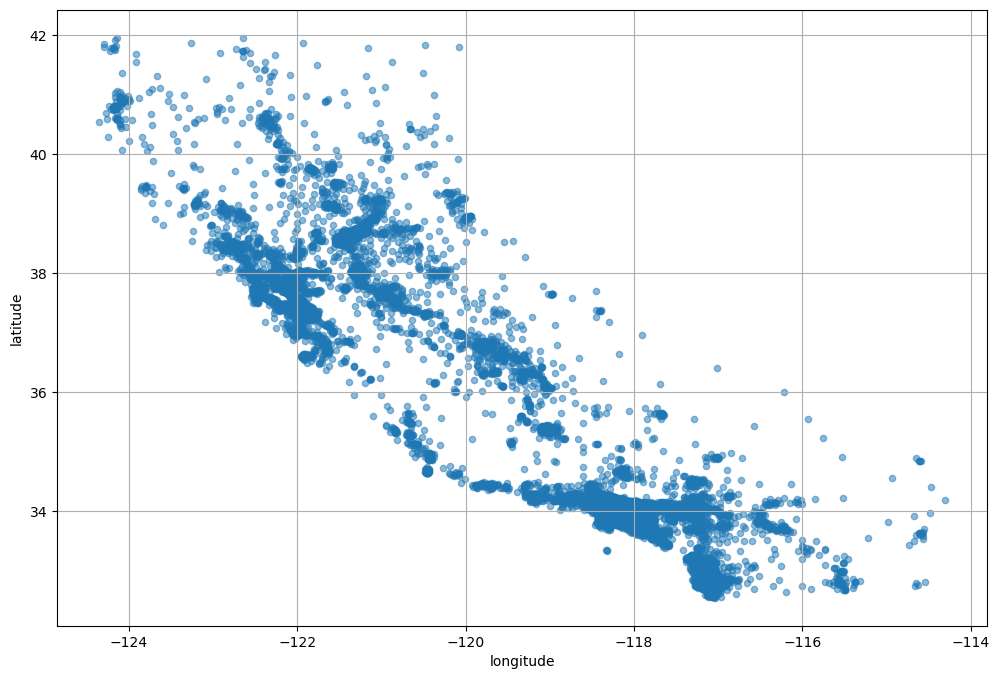

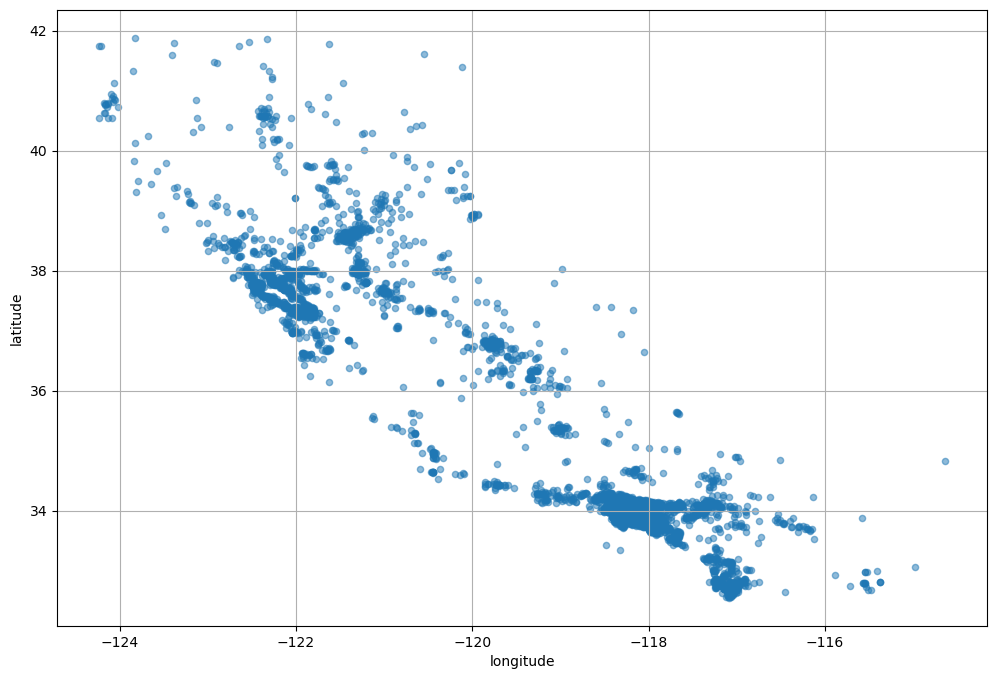

In [17]:
strat_train_set.plot(kind="scatter",x="longitude",y="latitude", grid=True , figsize=(12,8),alpha=0.5)
strat_test_set.plot(kind="scatter",x="longitude",y="latitude", grid=True , figsize=(12,8),alpha=0.5)
plt.show()

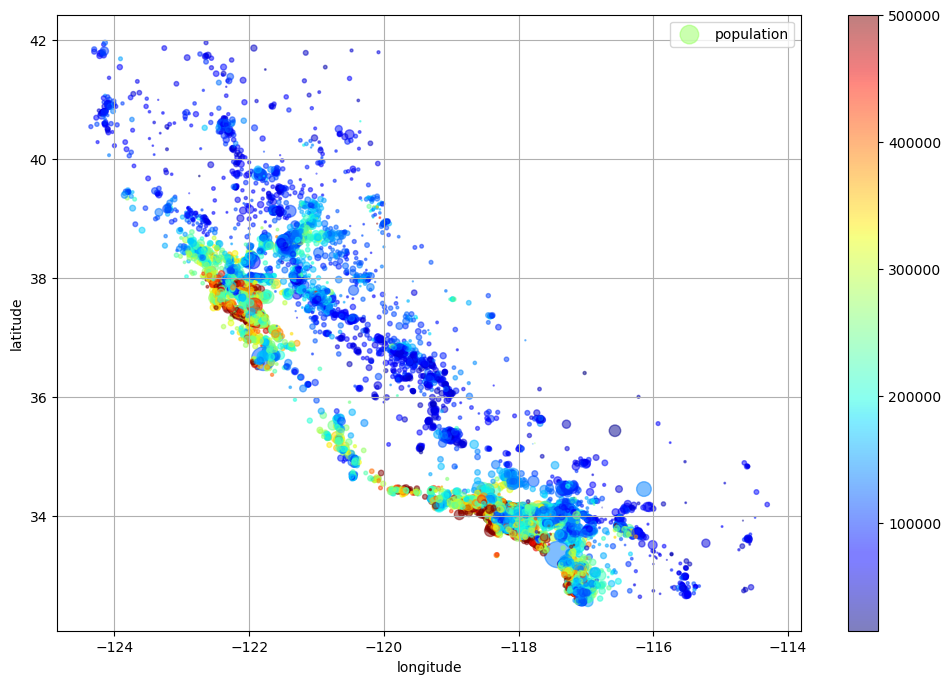

In [18]:
strat_train_set.plot(kind="scatter" , x="longitude",y="latitude", grid=True , figsize=(12,8),alpha=0.5,
                    s=strat_train_set["population"]/100 , c=strat_train_set["median_house_value"],cmap="jet",
                    label = "population" ,sharex=False,legend=True)
plt.show()

## try combinations of features or transform some given feature and check how it correlates to the target

In [19]:
strat_train_set.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
3012,-117.69,33.55,3.0,1618.0,266.0,710.0,246.0,6.0743,274300.0,<1H OCEAN,4
16951,-118.29,33.88,32.0,2307.0,493.0,1754.0,528.0,4.3170,232800.0,<1H OCEAN,3
14747,-117.64,34.05,32.0,1129.0,251.0,1378.0,268.0,3.0057,96900.0,INLAND,2
3846,-117.22,32.81,24.0,730.0,196.0,335.0,203.0,3.5078,362500.0,NEAR OCEAN,2
12574,-121.71,36.88,19.0,2528.0,554.0,2332.0,492.0,3.7766,177000.0,<1H OCEAN,2


In [20]:
new_housing = strat_train_set.drop(columns=["ocean_proximity"])
# new_housing.corr(housing["median_house_value"])
corr_matrix = new_housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687625
income_cat            0.630208
total_rooms           0.138470
housing_median_age    0.100729
households            0.068063
total_bedrooms        0.052905
population           -0.025029
longitude            -0.039394
latitude             -0.149820
Name: median_house_value, dtype: float64

#### - if we see the data there are some feature that may not be helpfull, for example
        - total_rooms in a district.
        - total_bedrooms in a district.
#### - instead we can derive other features from these , for example
        - total_rooms per house.
        - ratio between total_bedrooms and total_rooms
        - number of people per house.

In [21]:
#adding the feature 'people_per_house'
strat_train_set["people_per_house"] = strat_train_set["population"] / strat_train_set["households"]

# adding the feature total_bedrooms to total_rooms ration
strat_train_set["bedrooms_ratio"] = strat_train_set["total_bedrooms"] / strat_train_set["total_rooms"]

# adding the feature total_rooms per house
strat_train_set["rooms_per_house"] = strat_train_set["total_rooms"] / strat_train_set["households"]

In [22]:
new_housing = strat_train_set.drop(columns=["ocean_proximity"])
# new_housing.corr(housing["median_house_value"])
corr_matrix = new_housing.corr()
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687625
income_cat            0.630208
rooms_per_house       0.149741
total_rooms           0.138470
housing_median_age    0.100729
households            0.068063
total_bedrooms        0.052905
people_per_house     -0.022009
population           -0.025029
longitude            -0.039394
latitude             -0.149820
bedrooms_ratio       -0.253359
Name: median_house_value, dtype: float64

## what did you see

------------------------------------------
## Prepare the data for ML model training

In [23]:
housing = strat_train_set.drop(columns=["median_house_value"], axis=1)
housing_label = strat_train_set["median_house_value"].copy()

In [24]:
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        164
population              0
households              0
median_income           0
ocean_proximity         0
income_cat              0
people_per_house        0
bedrooms_ratio        164
rooms_per_house         0
dtype: int64

#### - here we can see that there are some columns with null values , to tackle this
        - best way to deal this is using **IMPUTER** method
        - there are many strategies that can be applied "mean" , "meadian" , "most_frequent" , "constant" etc
        - and there are advanced Imputer techniques too.

#### - main advatage of it is we can use this once we fit and transform a Imputer this will be applied to all the columns at once

In [25]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median") # since the most of the feature is median value of a district

In [26]:
# note the strategy mean and median can only be applied to numerical columns
# we are taking all the numerical columns
housing_num = housing.select_dtypes(include=[np.number])

imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [27]:
imputer.statistics_         #both the below and this values are same

array([-1.18490000e+02,  3.42500000e+01,  2.90000000e+01,  2.11800000e+03,
        4.33000000e+02,  1.16500000e+03,  4.08000000e+02,  3.52955000e+00,
        2.82120149e+00,  2.03455340e-01,  5.22383832e+00])

In [28]:
housing_num.median().values              #both the above and this values are same

array([-1.18490000e+02,  3.42500000e+01,  2.90000000e+01,  2.11800000e+03,
        4.33000000e+02,  1.16500000e+03,  4.08000000e+02,  3.52955000e+00,
        2.82120149e+00,  2.03455340e-01,  5.22383832e+00])

In [29]:
X = imputer.transform(housing_num)

#### KNN-IMPUTER

In [30]:
from sklearn.impute import KNNImputer

k_impute = KNNImputer(n_neighbors=10 , weights="distance")

k_x = k_impute.fit_transform(housing_num)       # you will get a numpy array

In [31]:
# # from sklearn.impute import IterativeImputer
# from sklearn.experimental import enable_iterative_imputer

# iter_impute = enable_iterative_imputer(initial_strategy="median")

# iter_x = iter_impute.fit_transform(housing_num)

In [32]:
arr = housing_num.columns.to_numpy()

In [33]:
arr

array(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'people_per_house', 'bedrooms_ratio', 'rooms_per_house'],
      dtype=object)

In [34]:
housing_num.index

Index([ 3012, 16951, 14747,  3846, 12574,  9947, 14256, 11317,  7706, 11669,
       ...
       12344,  6078, 15577,  8344, 11973, 12798,  7300, 11551,  2726, 16073],
      dtype='int64', length=16512)

In [35]:
housing_tr = pd.DataFrame(X , columns=arr , index=housing_num.index)

In [36]:
housing_tr.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
people_per_house      0
bedrooms_ratio        0
rooms_per_house       0
dtype: int64

In [37]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,people_per_house,bedrooms_ratio,rooms_per_house
3012,-117.69,33.55,3.0,1618.0,266.0,710.0,246.0,6.0743,2.886179,0.164400,6.577236
16951,-118.29,33.88,32.0,2307.0,493.0,1754.0,528.0,4.3170,3.321970,0.213697,4.369318
14747,-117.64,34.05,32.0,1129.0,251.0,1378.0,268.0,3.0057,5.141791,0.222321,4.212687
3846,-117.22,32.81,24.0,730.0,196.0,335.0,203.0,3.5078,1.650246,0.268493,3.596059
12574,-121.71,36.88,19.0,2528.0,554.0,2332.0,492.0,3.7766,4.739837,0.219146,5.138211


#### Handling text and categorical data

In [38]:
housing_cat = housing[["ocean_proximity"]]
housing_cat.head()

,ocean_proximity
3012,<1H OCEAN
16951,<1H OCEAN
14747,INLAND
3846,NEAR OCEAN
12574,<1H OCEAN


In [39]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()

housing_cat_encoded = encoder.fit_transform(housing_cat)


In [40]:
housing_cat_encoded.toarray()

array([[1., 0., 0., 0., 0.],
       [1., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0.],
       ...,
       [0., 0., 0., 1., 0.],
       [0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 1.]])

In [41]:
encoder.feature_names_in_

array(['ocean_proximity'], dtype=object)

In [42]:
encoder.get_feature_names_out()

array(['ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND',
       'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY',
       'ocean_proximity_NEAR OCEAN'], dtype=object)

In [43]:
housing_label_tr = pd.DataFrame(housing_cat_encoded.toarray() , columns=encoder.get_feature_names_out() , index=housing_cat.index)

In [44]:
housing_label_tr.head()

,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
3012,1.0,0.0,0.0,0.0,0.0
16951,1.0,0.0,0.0,0.0,0.0
14747,0.0,1.0,0.0,0.0,0.0
3846,0.0,0.0,0.0,0.0,1.0
12574,1.0,0.0,0.0,0.0,0.0


In [45]:
housing_label_tr.isnull().sum()

ocean_proximity_<1H OCEAN     0
ocean_proximity_INLAND        0
ocean_proximity_ISLAND        0
ocean_proximity_NEAR BAY      0
ocean_proximity_NEAR OCEAN    0
dtype: int64

## FEATURE SCALING
    - MinMax Scalling

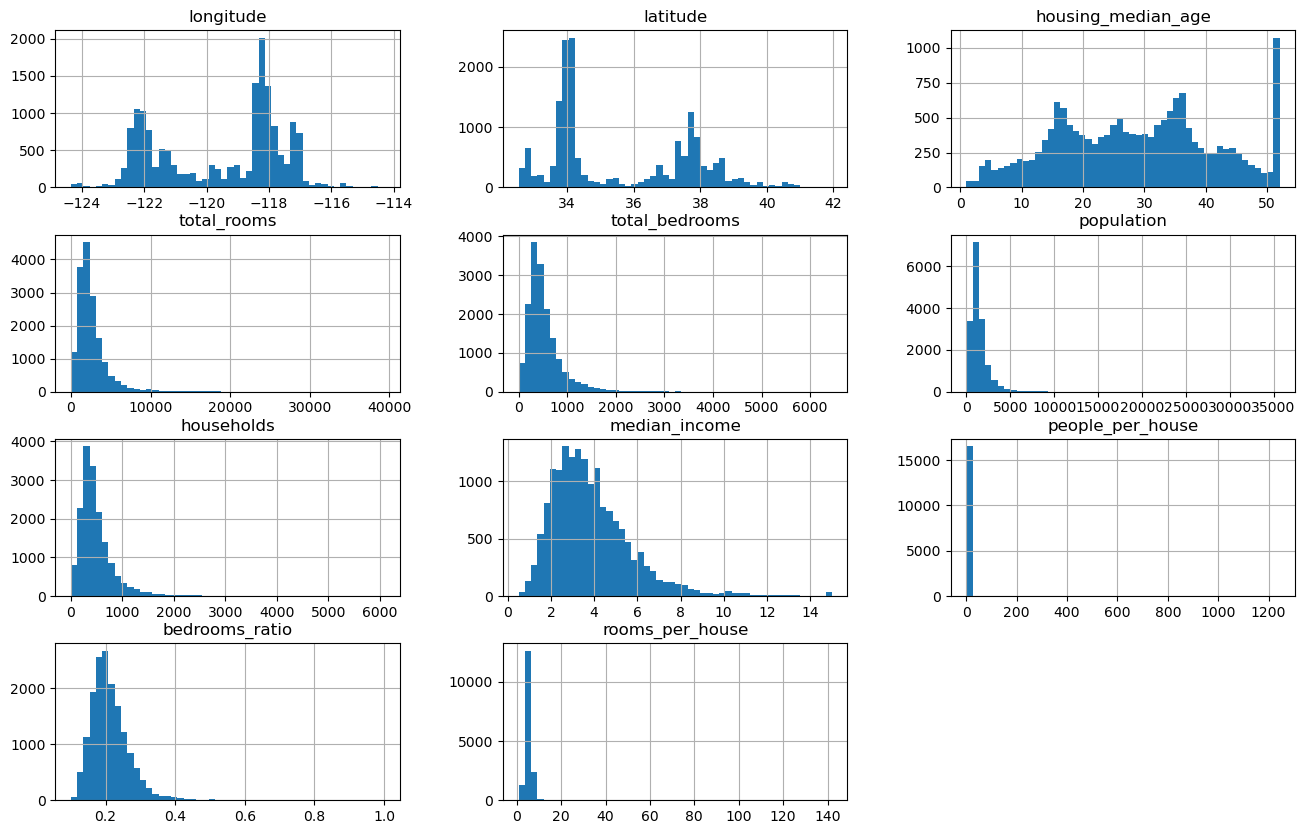

In [46]:
housing_num.hist(bins=50 , figsize=(16,10))
plt.show()

In [47]:
from sklearn.preprocessing import MinMaxScaler

m_scaler = MinMaxScaler(feature_range=(-1,1))

housing_num_m_scaled = m_scaler.fit_transform(housing_num)

In [48]:
X = pd.DataFrame(housing_num_m_scaled , columns=housing_num.columns , index=housing_num.index)

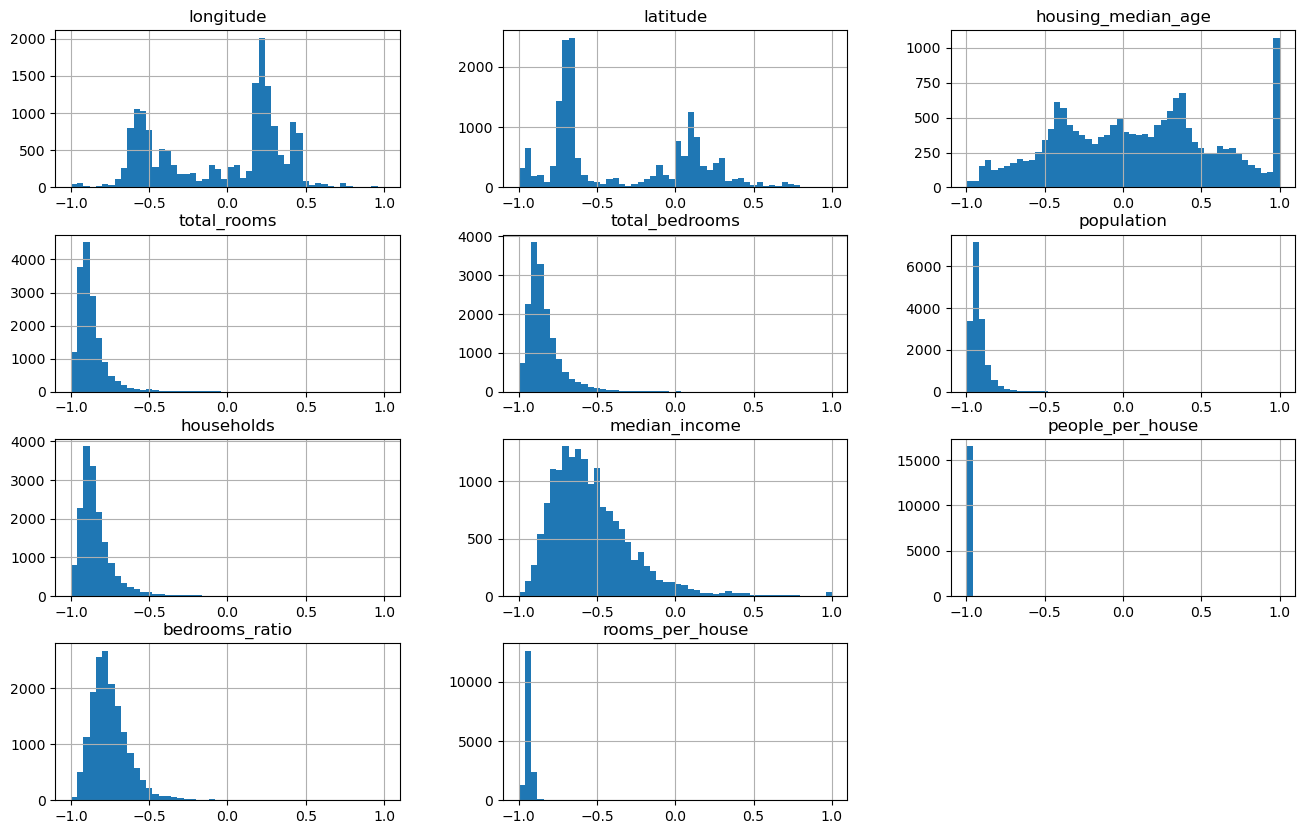

In [49]:
X.hist(bins=50 , figsize=(16,10))
plt.show()

- standard scaler

In [50]:
from sklearn.preprocessing import StandardScaler

s_scaler = StandardScaler()

housing_num_s_scaled = s_scaler.fit_transform(housing_num)

In [51]:
X = pd.DataFrame(housing_num_s_scaled , columns=housing_num.columns , index=housing_num.index)
X.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,people_per_house,bedrooms_ratio,rooms_per_house
3012,0.934709,-0.973167,-2.032773,-0.468978,-0.646698,-0.635675,-0.665688,1.163168,-0.018778,-0.833510,0.447728
16951,0.635457,-0.818561,0.266639,-0.144191,-0.098295,0.306484,0.084586,0.237585,0.018780,0.008498,-0.412350
14747,0.959647,-0.738915,0.266639,-0.699487,-0.682937,-0.032838,-0.607156,-0.453087,0.175620,0.155785,-0.473365
3846,1.169123,-1.319861,-0.367682,-0.887572,-0.815810,-0.974093,-0.780091,-0.188627,-0.125296,0.944427,-0.713568
12574,-1.070276,0.586956,-0.764132,-0.040013,0.049074,0.828100,-0.011193,-0.047048,0.140978,0.101554,-0.112833


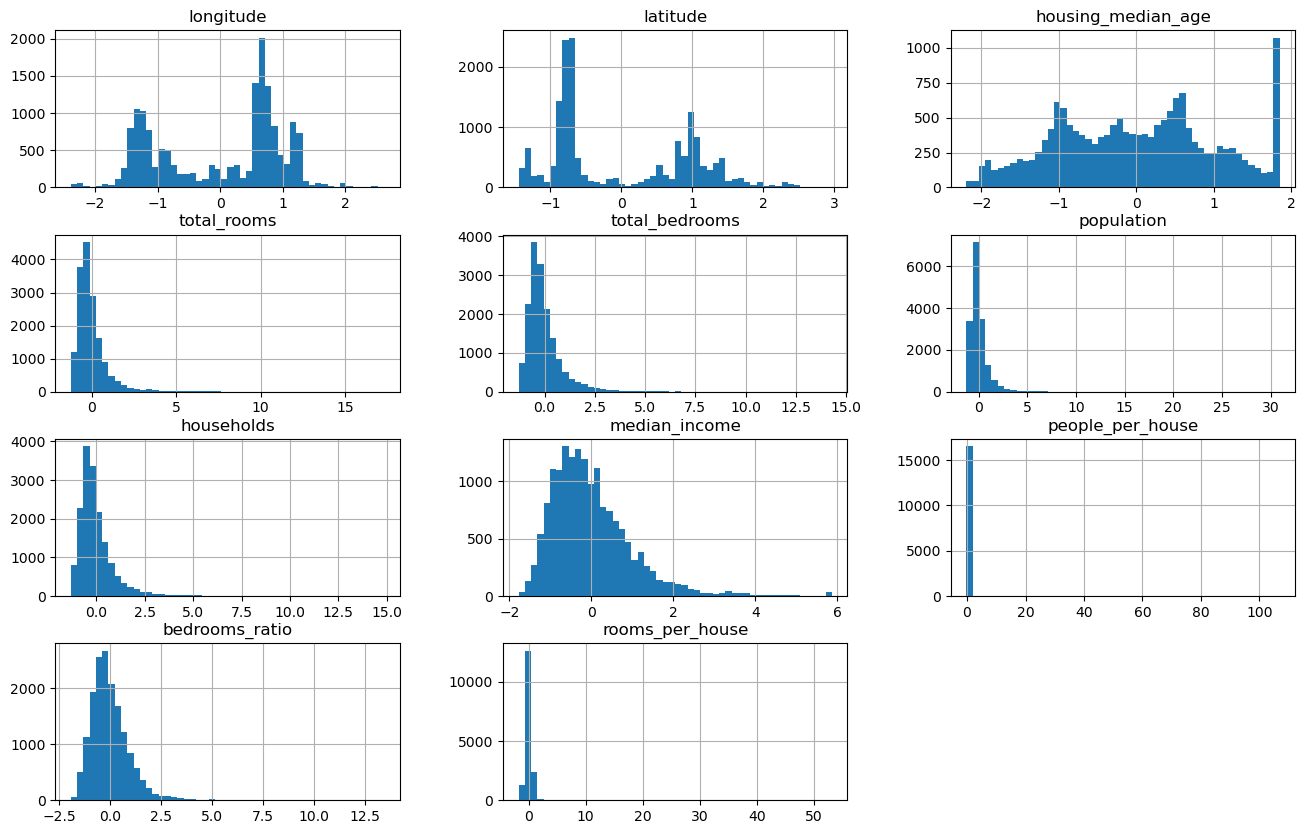

In [52]:
X.hist(bins=50 , figsize=(16,10))
plt.show()

##### even after feature scalling the graph seams the same right
##### but x-axis range is changed

### - to deal with right skewed graphs we can apply tranformation like 
    - log_transformers (for feature that has higher range (15-6000)) or 
    - square transformer (for shorter range (0-15))

In [53]:
# since all the feature has shorter range we can apply tranform now , you may think.
# but we need to transform and then scale the features

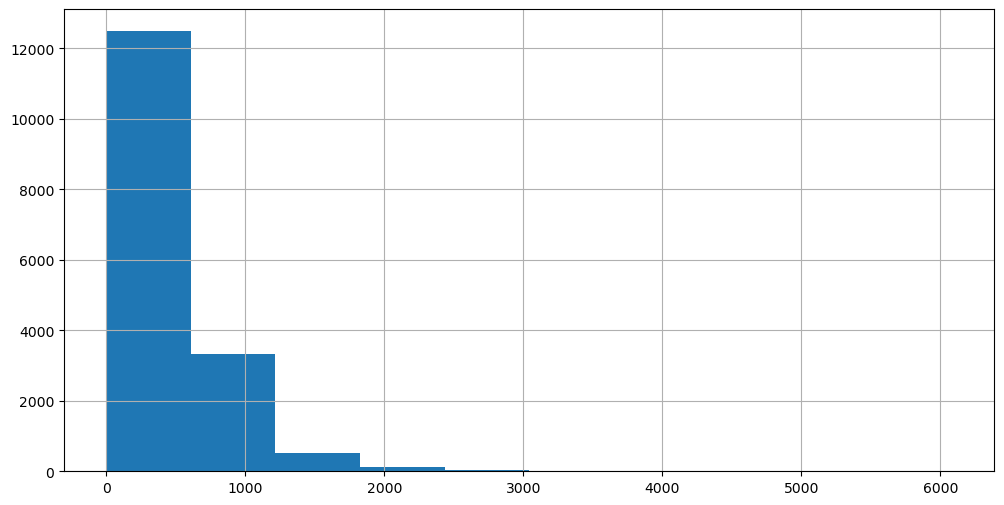

In [54]:
housing_num["households"].hist(figsize=(12,6))
plt.show()

In [55]:
# log_transform

from sklearn.preprocessing import FunctionTransformer

log_trans = FunctionTransformer(np.log , inverse_func=np.exp)

log_pop = log_trans.transform(housing_num[["population"]])

In [56]:
log_pop.head()

,population
3012,6.565265
16951,7.469654
14747,7.228388
3846,5.814131
12574,7.754482


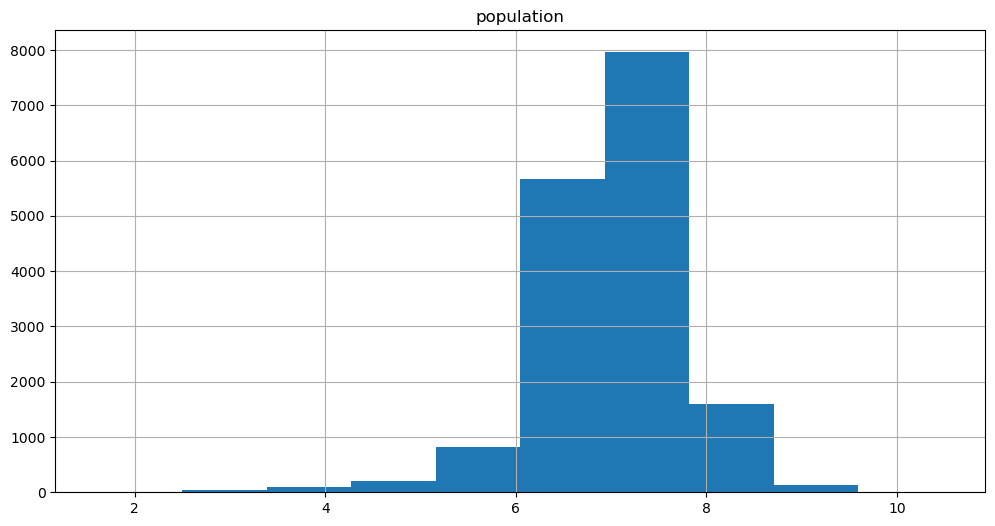

In [57]:
log_pop.hist(figsize=(12,6))
plt.show()

In [58]:
log_pop_scaled = s_scaler.fit_transform(log_pop)

In [60]:
pop = pd.DataFrame(log_pop_scaled , columns=log_pop.columns , index=log_pop.index)

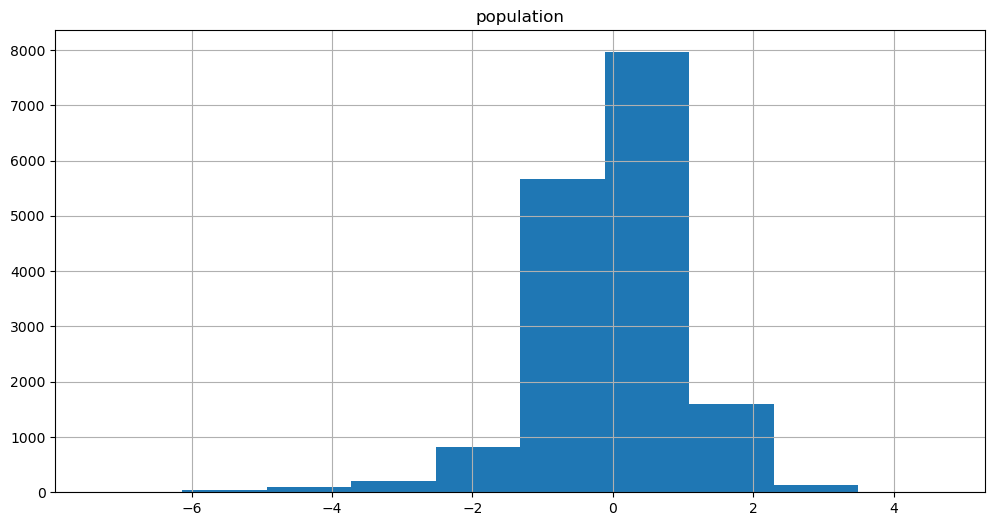

In [61]:
pop.hist(figsize=(12,6))
plt.show()